In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

In [5]:
# ── Load Model & Data ─────────────────────────────────────
xgb_model = joblib.load('models/xgboost_fraud_model.pkl')
X_test    = pd.read_csv('../data/processed/X_test.csv')
y_test    = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Loaded model and test data: {X_test.shape}")

Loaded model and test data: (118108, 223)


In [6]:

# ============================================================
# STEP 1: SAMPLE DATA FOR SHAP
# Reason: SHAP on 118K rows is computationally expensive.A 2,000-row stratified sample preserves fraud ratio while keeping computation fast.
# ============================================================

sample_size = 2000
fraud_idx    = y_test[y_test == 1].index
legit_idx    = y_test[y_test == 0].index

# Stratified sample matching original fraud ratio
n_fraud = int(sample_size * y_test.mean())
n_legit = sample_size - n_fraud

sample_fraud_idx = np.random.choice(fraud_idx, size=min(n_fraud, len(fraud_idx)), replace=False)
sample_legit_idx = np.random.choice(legit_idx, size=n_legit, replace=False)
sample_idx = np.concatenate([sample_fraud_idx, sample_legit_idx])

X_sample = X_test.loc[sample_idx]
y_sample = y_test.loc[sample_idx]

print(f"\n[STEP 1] SHAP Sample Created")
print(f"  Sample size: {len(X_sample)}")
print(f"  Fraud cases: {y_sample.sum()}")
print(f"  Fraud rate : {y_sample.mean()*100:.2f}%")


[STEP 1] SHAP Sample Created
  Sample size: 2000
  Fraud cases: 69
  Fraud rate : 3.45%


In [7]:
# ============================================================
# STEP 2: CALCULATE SHAP VALUES
# Reason: TreeExplainer is exact and fast for XGBoost — no approximation needed unlike KernelExplainer
# ============================================================

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

print(f"\n[STEP 2] SHAP values calculated")
print(f"  Shape: {shap_values.shape}")


[STEP 2] SHAP values calculated
  Shape: (2000, 223)


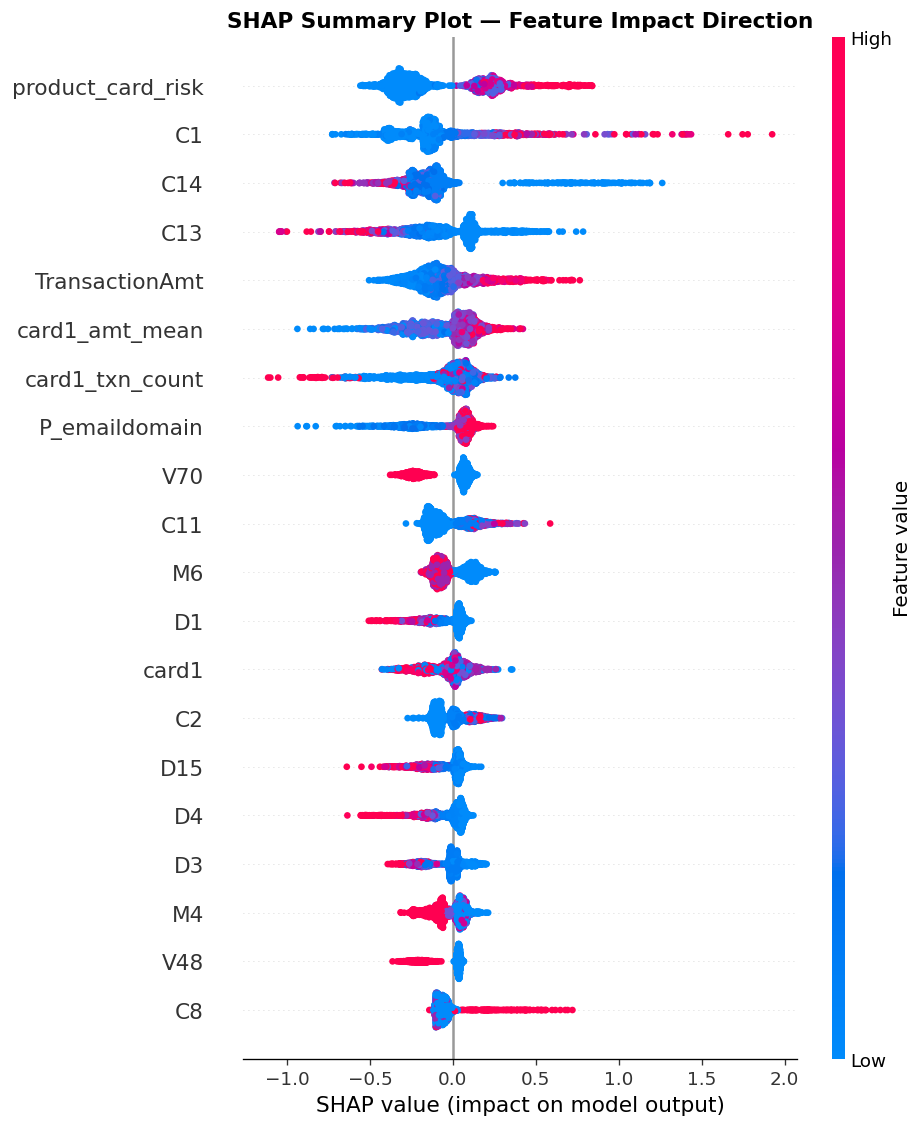


[STEP 3] SHAP summary plot saved
  Red = pushes prediction toward FRAUD
  Blue = pushes prediction toward LEGITIMATE


In [8]:
# ============================================================
# STEP 3: GLOBAL FEATURE IMPORTANCE (SHAP Summary)
# Business Question: Across ALL predictions, which features matter most, and in which direction?
# ============================================================

plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP Summary Plot — Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_01_summary.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n[STEP 3] SHAP summary plot saved")
print("  Red = pushes prediction toward FRAUD")
print("  Blue = pushes prediction toward LEGITIMATE")

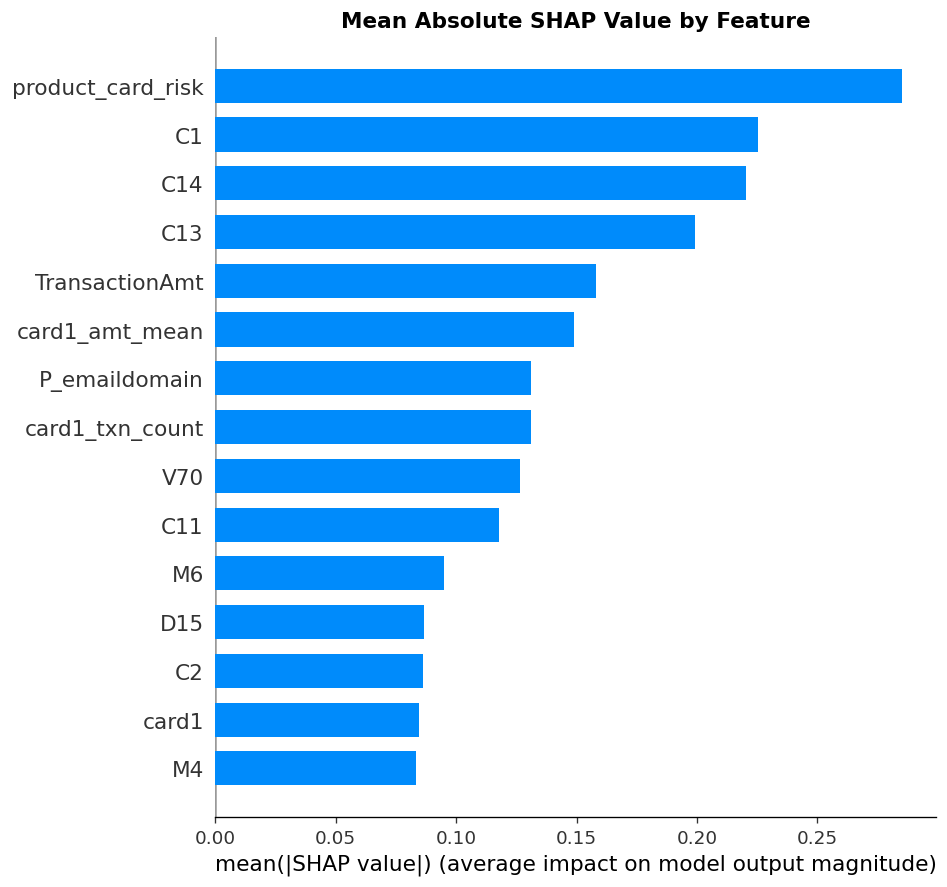

In [6]:
# ============================================================
# STEP 4: SHAP BAR PLOT (Mean Absolute Impact)
# Cleaner version for presentations — no direction,just magnitude of impact
# ============================================================

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('Mean Absolute SHAP Value by Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_02_bar.png', bbox_inches='tight', dpi=120)
plt.show()

In [9]:
# ============================================================
# STEP 5: VALIDATE ENGINEERED FEATURES
# Business Question: Did the features WE built actually contribute, or did V-columns dominate?
# ============================================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

engineered_features = [
    'is_peak_fraud_hour', 'time_of_day', 'is_weekend',
    'amt_bucket', 'is_round_amount', 'is_high_value',
    'card4_risk_score', 'card6_risk_score', 'ProductCD_risk_score',
    'card1_txn_count', 'card1_amt_mean', 'amt_deviation_card1',
    'is_high_deviation', 'c_cols_sum', 'c_cols_mean', 'c_cols_max',
    'v_cols_sum', 'v_cols_mean', 'v_cols_std',
    'high_value_peak_hour', 'product_card_risk', 'amt_log_x_hour'
]

eng_importance = shap_importance[shap_importance['feature'].isin(engineered_features)]
eng_importance['rank'] = shap_importance.reset_index(drop=True).index[
    shap_importance['feature'].isin(engineered_features)
] + 1

print(f"\n[STEP 5] Engineered Feature Performance (Ranked)")
print(eng_importance.to_string(index=False))

n_in_top20 = shap_importance.head(20)['feature'].isin(engineered_features).sum()
print(f"\n  Engineered features in Top 20: {n_in_top20} out of {len(engineered_features)} built")


[STEP 5] Engineered Feature Performance (Ranked)
             feature  mean_abs_shap  rank
   product_card_risk       0.286435     1
      card1_amt_mean       0.147273     6
     card1_txn_count       0.133537     7
     is_round_amount       0.046943    33
          c_cols_sum       0.045224    34
          v_cols_sum       0.042772    35
ProductCD_risk_score       0.033690    41
 amt_deviation_card1       0.028961    45
  is_peak_fraud_hour       0.026866    48
      amt_log_x_hour       0.021888    53
          v_cols_std       0.020388    54
          c_cols_max       0.019210    57
    card6_risk_score       0.018030    59
    card4_risk_score       0.016845    62
         c_cols_mean       0.012556    68
         v_cols_mean       0.004923   104
         time_of_day       0.003635   119
          amt_bucket       0.002280   138
       is_high_value       0.000937   175
          is_weekend       0.000709   184
   is_high_deviation       0.000641   185
high_value_peak_hour      

<Figure size 1440x480 with 0 Axes>

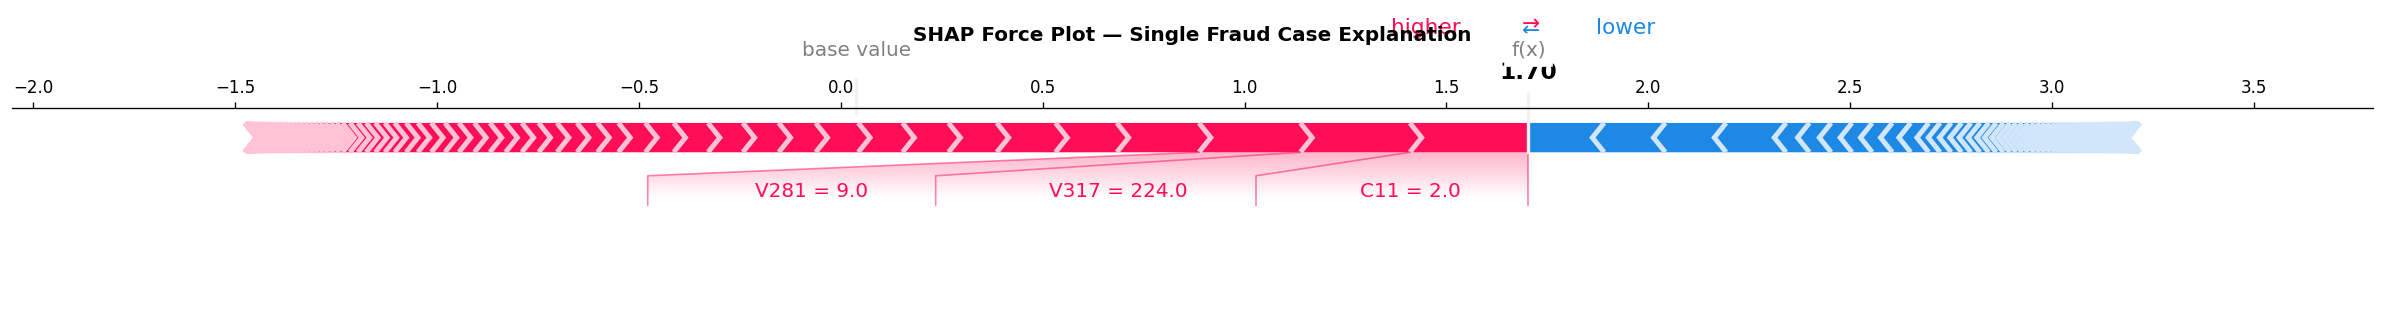


[STEP 6] Individual case explained (index 0)
  Predicted probability: 0.8459
  Actual label: Fraud


In [8]:
# ============================================================
# STEP 6: INDIVIDUAL FRAUD CASE EXPLANATION
# Business Question: Why did the model flag THIS specific transaction as fraud? (Critical for fraud analyst teams reviewing flags)
# ============================================================

# Pick a true positive case (correctly caught fraud)
y_pred_sample = xgb_model.predict_proba(X_sample)[:, 1]
true_positive_mask = (y_sample.values == 1) & (y_pred_sample >= 0.8)

if true_positive_mask.sum() > 0:
    tp_idx = np.where(true_positive_mask)[0][0]

    plt.figure(figsize=(12, 4))
    shap.force_plot(
        explainer.expected_value,
        shap_values[tp_idx],
        X_sample.iloc[tp_idx],
        matplotlib=True, show=False
    )
    plt.title('SHAP Force Plot — Single Fraud Case Explanation', fontsize=12, fontweight='bold', y=1.3)
    plt.tight_layout()
    plt.savefig('../reports/shap_03_force_plot_fraud_case.png', bbox_inches='tight', dpi=120)
    plt.show()

    print(f"\n[STEP 6] Individual case explained (index {tp_idx})")
    print(f"  Predicted probability: {y_pred_sample[tp_idx]:.4f}")
    print(f"  Actual label: Fraud")

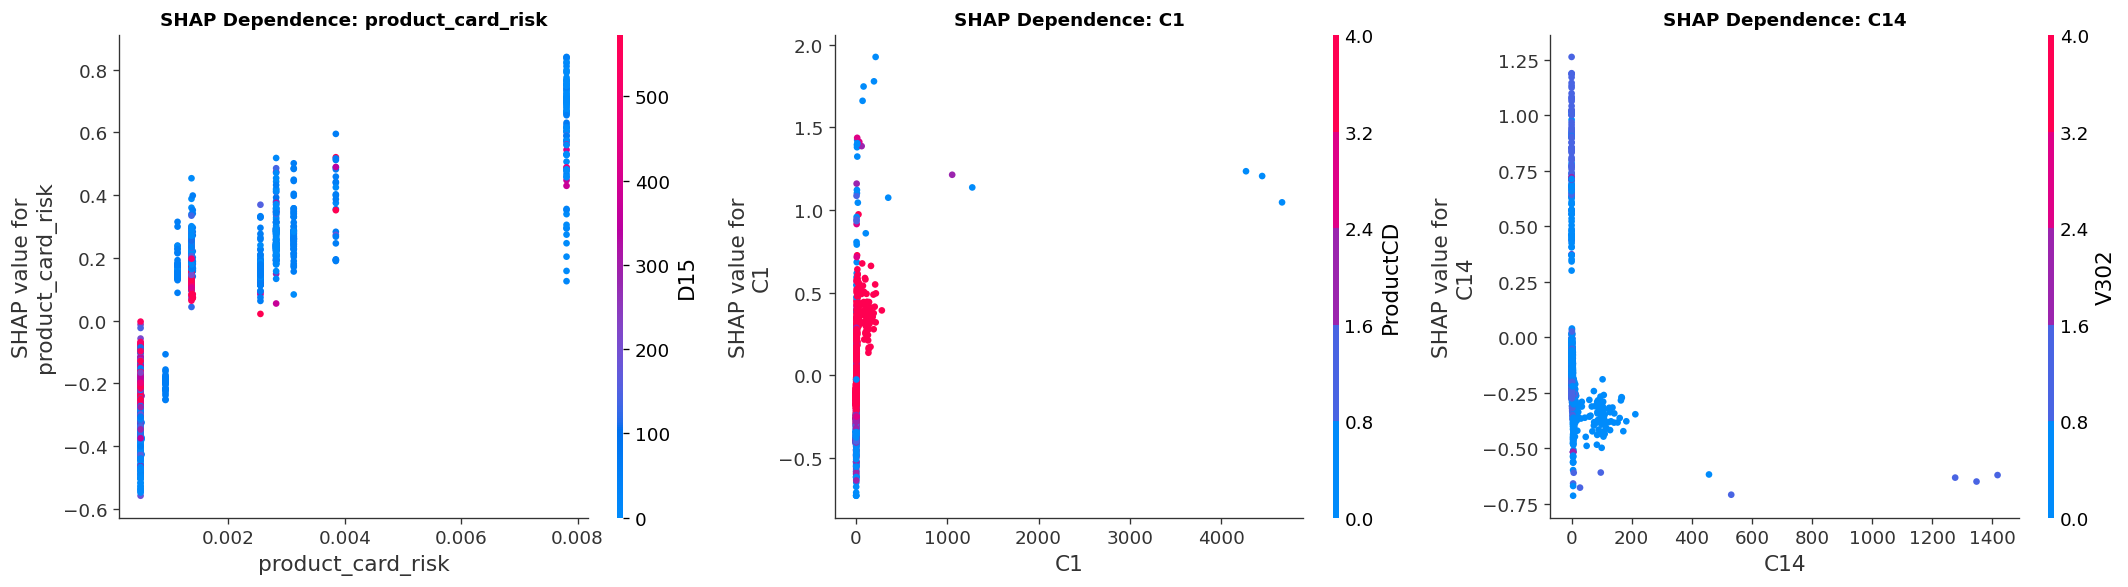


[STEP 7] Dependence plots created for: ['product_card_risk', 'C1', 'C14']


In [10]:
# ============================================================
# STEP 7: DEPENDENCE PLOTS FOR TOP 3 FEATURES
# Business Question: How does each top feature's VALUE relate to its impact on fraud risk?
# ============================================================

top_3_features = shap_importance.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top_3_features):
    shap.dependence_plot(
        feat, shap_values, X_sample,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/shap_04_dependence_plots.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n[STEP 7] Dependence plots created for: {top_3_features}")

In [11]:
# ============================================================
# STEP 8: SAVE SHAP IMPORTANCE TABLE
# ============================================================

shap_importance.to_csv('../reports/shap_importance.csv', index=False)

print("========== PHASE 7 SUMMARY ==========")
print("Top 5 SHAP Features:")
print(f"{shap_importance.head(5).to_string(index=False)}")
print(f"Engineered features in Top 20: {n_in_top20}")
print("======================================")

========== PHASE 7 SUMMARY ==========
Top 5 SHAP Features:
          feature  mean_abs_shap
product_card_risk       0.286435
               C1       0.226003
              C14       0.219224
              C13       0.203730
   TransactionAmt       0.153686
Engineered features in Top 20: 3
